# Loan Default Risk - Exploratory Data Analysis

# Business Problem
The bank aims to reduce loan default rates by identifying high-risk borrowers and improving loan approval decisions.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

# Dataset Overview

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# Data Cleaning

In [8]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

In [10]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df['loan_int_rate'].median()
)

In [11]:
df.duplicated().sum()

np.int64(165)

In [12]:
df = df.drop_duplicates()

In [13]:
df['person_age'].describe()

count    32416.000000
mean        27.747008
std          6.354100
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [14]:
df = df[df['person_age'] <= 100]

In [15]:
df['person_emp_length'].describe()

count    32411.000000
mean         4.768720
std          4.090478
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [16]:
df = df[df['person_emp_length'] <= 60]

In [ ]:
df = df[df['person_income'] > 0]

# Feature Engineering

LTI (Loan-to-Income Ratio) is created to measure the borrower's financial burden relative to income.

In [17]:
df['LTI'] = df['loan_amnt'] / df['person_income']

In [18]:
def risk_segment(lti):
    if lti < 0.2:
        return 'Low Risk'
    elif lti < 0.4:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['risk_segment'] = df['LTI'].apply(risk_segment)

In [19]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,LTI,risk_segment
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,Low Risk
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,High Risk
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,High Risk
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,High Risk
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,Medium Risk


# Exploratory Data Analysis

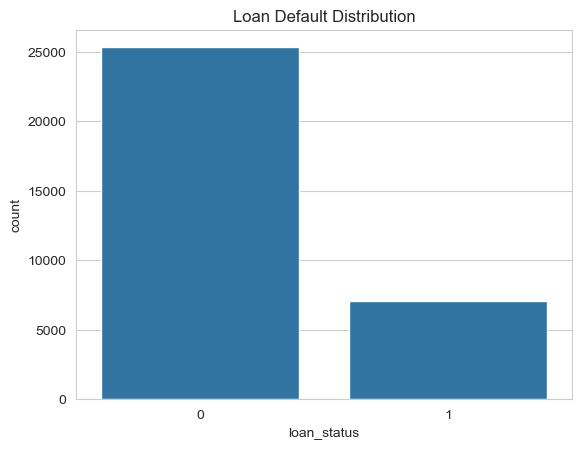

In [20]:
sns.countplot(x='loan_status', data=df)

plt.title("Loan Default Distribution")

plt.show()

Most borrowers do not default, although a significant proportion still presents repayment risk.

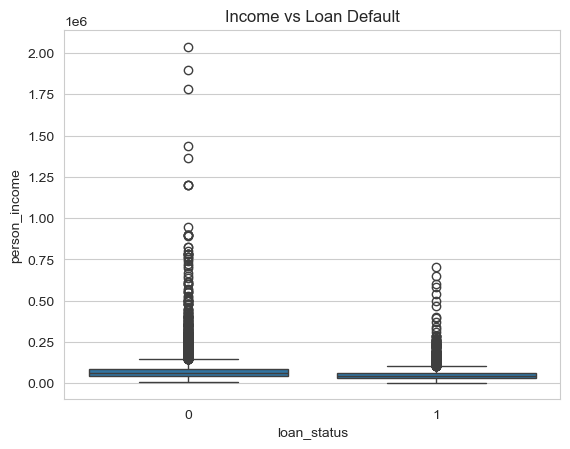

In [21]:
sns.boxplot(
    x='loan_status',
    y='person_income',
    data=df
)

plt.title("Income vs Loan Default")

plt.show()

Lower-income borrowers tend to show higher default tendencies.

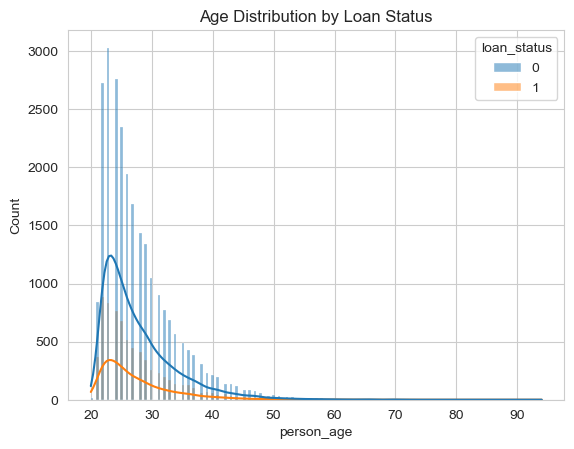

In [22]:
sns.histplot(
    data=df,
    x='person_age',
    hue='loan_status',
    kde=True
)

plt.title("Age Distribution by Loan Status")

plt.show()

Younger borrowers appear slightly more likely to default.

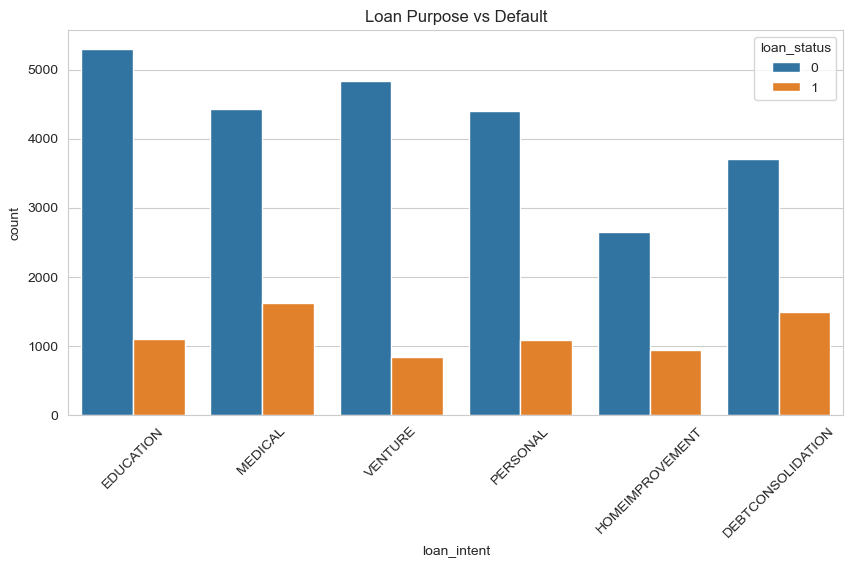

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='loan_intent',
    hue='loan_status',
    data=df
)

plt.xticks(rotation=45)

plt.title("Loan Purpose vs Default")

plt.show()

Personal and medical loans demonstrate relatively higher repayment risk.

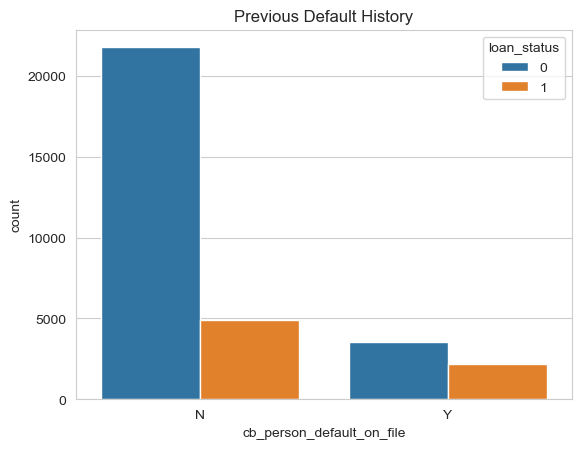

In [24]:
sns.countplot(
    x='cb_person_default_on_file',
    hue='loan_status',
    data=df
)

plt.title("Previous Default History")

plt.show()

Borrowers with previous default records exhibit substantially higher delinquency risk.

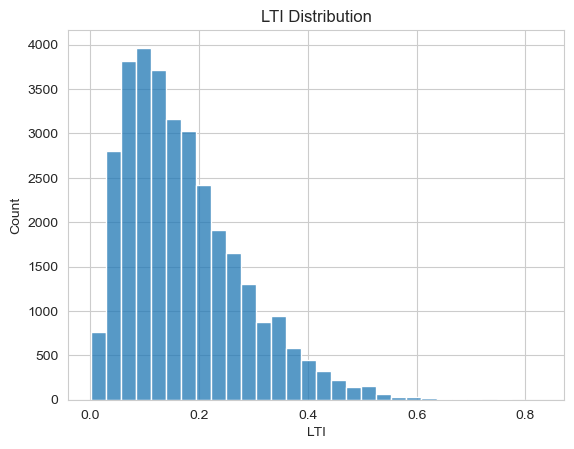

In [25]:
sns.histplot(df['LTI'], bins=30)

plt.title("LTI Distribution")

plt.show()

Most borrowers maintain relatively low LTI ratios, although several high-risk outliers are visible.

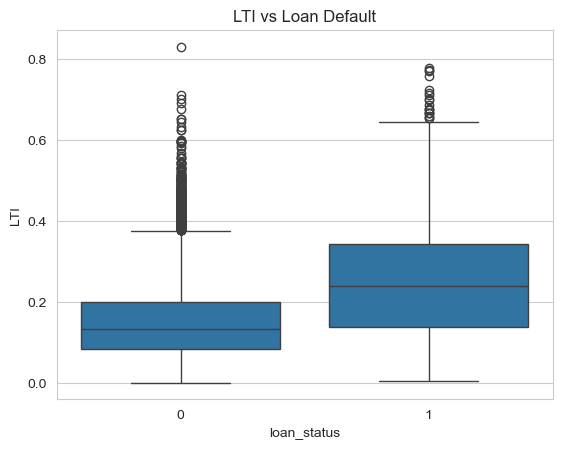

In [ ]:
sns.boxplot(
    x='loan_status',
    y='LTI',
    data=df
)

plt.title("LTI vs Loan Default")

plt.show()

High-LTI borrowers are considerably more likely to default.

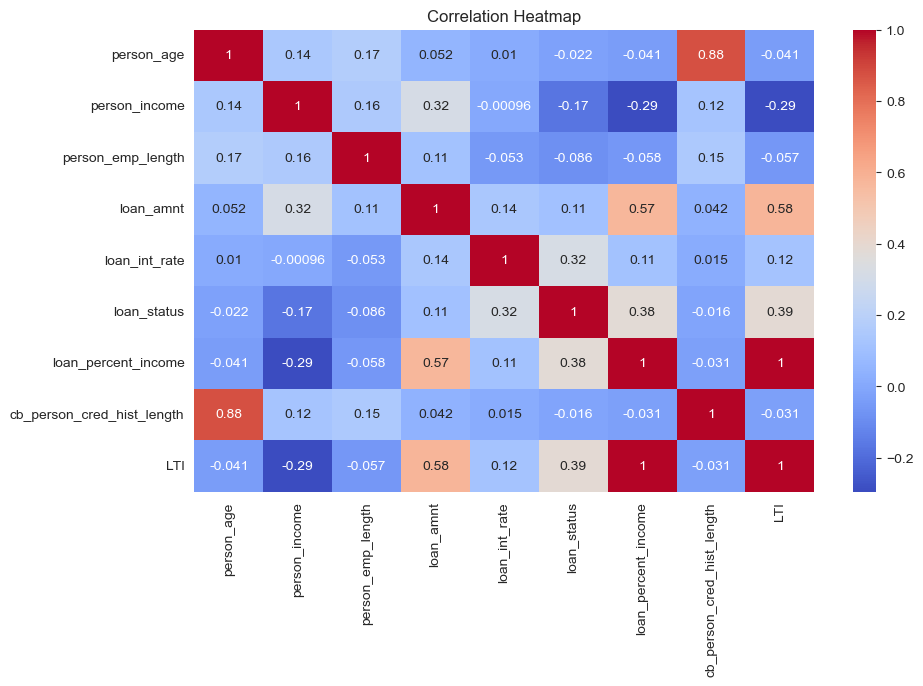

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Several financial variables, particularly LTI and income-related metrics, display meaningful relationships with loan default behavior.

# Business Insights
1. High-LTI borrowers demonstrate significantly higher default risk.
2. Previous default history strongly correlates with delinquency.
3. Certain loan purposes carry elevated repayment risk.
4. Lower-income borrowers are more vulnerable to loan default.

# Recommendations
1. Tighten approval rules for high-LTI applicants.
2. Apply additional verification procedures for borrowers with prior defaults.
3. Increase monitoring for risky loan categories.
4. Consider implementing risk-based interest pricing for higher-risk borrowers.

# Conclusion
This analysis identifies several important risk indicators associated with loan default, including high LTI, low income, and previous delinquency history. These findings may support more effective credit risk management and loan approval strategies.